<center><h1>Eigenvalue approximation</h1></center>
<center><h3>The QR method</h3></center>

- - - - - - - - - - - - - - -

In [1]:
import numpy as np
from IPython.display import Image

- - - - - - - - - - - - - - -

In earthquake engineering, a model for the oscillatory motion of a structure after an initial disturbance is $Mx + Kx = 0$, or equivalently $y + Ay = 0$, where $x$ is a vector of displacements, $M$ and $K$ are matrices of mass and stiffness parameters, $A = M^{\frac{1}{2}}KM^{\frac{1}{2}}$ and $y = M^{\frac{1}{2}}x$. The general solution of this equation takes the form $y(t) = \sum_{k}[\alpha_{k}cos(\sqrt(\lambda_{t})t) + \beta_{k}sin(\sqrt(\lambda_{t})t)]v_{k}$, where $(\lambda_{k}, \space v_{k})$ are eigenpairs of $A$ and $(\alpha_{k}, \space \beta_{k})$ are arbitrary coefficients. Thus $\sqrt(\lambda_{k})$ represent the possible oscillatory frequencies of the structure: the lowest is called its fundamental frequency.

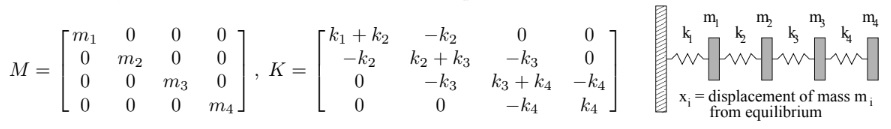

In [2]:
Image('displacement.jpg')

Here we use the <b>QR method</b> to determine all the eigenpairs of $A$ for a structure with $M$ and $K$ as shown and determine the fundamental frequency. We suppose $\{m_{1}, m_{2}, m_{3}, m_{4}\} = \{1, 3, 2, 5\}$ [kg] and $\{m_{1}, m_{2}, m_{3}, m_{4}\} = \{1, 3, 2, 5\}$ [N/m].

Use the <b>QR method</b> to find an approximation to all the eigenpairs of $A$ using a tolerance of $||R^{(k)}||_{\infty} \leq 10^{-5}$, where $R^{(k)}$ is the off-diagonal portion of $A^{(k)}$. Report the original matrix $A$, all its approximate eigenvalues $\lambda_{1}, \dots, \lambda_{4}$, ordered from largest to smallest in magnitude, and the lowest eigenpair $(\lambda_{4}, \space v_{4})$. What is the fundamental frequency $\omega = \sqrt(\lambda)$ [radian/sec] if the structure?

In [3]:
def qr(A, n, maxIter, tol):
    iter = 0
    error = 1
    
    B = A
    D = np.zeros((len(A[0]), len(A[0])))
    Q = np.eye(len(A[0]))

    '''The QR method used here uses Givens rotation, which uses the following matrix:'''
    '''| cos(theta)  sin(theta)|'''
    '''|-sin(theta)  cos(theta)|'''
    while(iter < maxIter and error >= tol):
        G = np.eye(len(A[0]))
        for i in range(1, n):
            P = np.eye(len(A[0]))
            Pt = np.eye(len(A[0]))
            
            theta = np.arctan(np.divide(B[i][i-1], B[i-1][i-1]))
    
            c = np.cos(theta)
            s = np.sin(theta)
    
            P[i][i] = c
            P[i-1][i-1] = c
            P[i][i-1] = -s
            P[i-1][i] = s
        
            Pt[i][i] = c
            Pt[i-1][i-1] = c
            Pt[i][i-1] = s
            Pt[i-1][i] = -s
    
            B = P @ B
            G = G @ Pt
        B = B @ G
        Q = Q @ G
        
        for i in range(n):
            D[i][i] = B[i][i]
        R = B - D
        '''With ord = np.inf, np.linalg.norm defaults to L-infinity norm.'''
        error = np.linalg.norm(R, np.inf)
        iter += 1

    return A, error, iter, D, Q

if __name__ == "__main__":
    A = np.array([[3, -1, 0, 0], [-1, 5, 0.5, 0], [0, 0.5, 4, -1], [0, 0, -1, 2]])
    A, error, iter, D, Q = qr(A, len(A[0]), 50, 1e-5)

    print('Given: A =')
    print(A)
    print(f'The solution converged with a |r|_(infinity) = {error}')
    print(f'Iterations needed: {iter}')
    print('Approximate eigenvalue matrix: D^(k) =')
    print(D)
    print('Approximate eigenvector matrix: Q^(k) =')
    print(Q)

Given: A =
[[ 3.  -1.   0.   0. ]
 [-1.   5.   0.5  0. ]
 [ 0.   0.5  4.  -1. ]
 [ 0.   0.  -1.   2. ]]
The solution converged with a |r|_(infinity) = 9.004388190760107e-06
Iterations needed: 43
Approximate eigenvalue matrix: D^(k) =
[[5.57985146 0.         0.         0.        ]
 [0.         4.27421356 0.         0.        ]
 [0.         0.         2.57395038 0.        ]
 [0.         0.         0.         1.5719846 ]]
Approximate eigenvector matrix: Q^(k) =
[[ 0.33871829  0.22189982 -0.91296161 -0.05031383]
 [-0.87384087 -0.28274471 -0.38896695 -0.07184893]
 [-0.33595414  0.85423992  0.061383    0.39197078]
 [ 0.09384489 -0.37561955 -0.10694827  0.91578663]]


## Further readings:
Reading material:<br>
https://www.amazon.com/Numerical-Analysis-Richard-L-Burden/dp/1305253663/

The @ symbol: <br>
https://stackoverflow.com/questions/6392739/what-does-the-at-symbol-do-in-python

## Useful links:
Quick definition:<br>
https://www.math.kth.se/na/SF2524/matber15/qrmethod.pdf <br>
https://student.cs.uwaterloo.ca/~cs475/CS475-Lecture13.pdf